# Preliminary Analysis on Base Questions

We used a updated clean dataset labeled 'arrdep_18augsep_simplecleaned.csv'.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Question 2.1

In [4]:
def wait_time(filename):

    # Loads the file
    file = pd.read_csv(filename)
    
    # Drops all NaN values in headway/scheduled_headways columns.
    no_nan_df = file.dropna(subset=['headway', 'scheduled_headway'])
    # Calculates the average headway/scheduled_headway per bus route.
    bus_time_wait = no_nan_df.groupby('route_id')[['headway', 'scheduled_headway']].mean()

    # Sorts the wait time in descending order
    sorted_df = bus_time_wait.sort_values(by=['scheduled_headway'], ascending = False)
    sorted_df["difference"] = sorted_df["headway"] - sorted_df["scheduled_headway"]

    # Plots the comparison between actual and scheduled headway per route
    plt.figure(figsize=(14, 6)) # Adjust figure size
    plt.scatter(sorted_df.index.astype(str), sorted_df["scheduled_headway"], color = "red", label = "Scheduled Headway") # Plots the scatterplots of route_id vs sceduled headway as "red"
    plt.scatter(sorted_df.index.astype(str), sorted_df["headway"], color = "blue", label='Actual Headway') # Plots the scatterplots of route_id vs actual headway as "blue"
    plt.xticks(rotation=270) 
    plt.xlabel('Route ID') 
    plt.ylabel('Time (in seconds)') 
    plt.title('Comparison of Actual and Scheduled Headway for Each Route')
    plt.legend()
    plt.tight_layout()
    plt.grid(True) # Adds grid lines for easier comparison
    plt.show()

    # Returns dataframe of average headway/scheduled headway per bus route in descending order.
    return sorted_df

#### Output

Scheduled wait time vs actual wait time per bus route

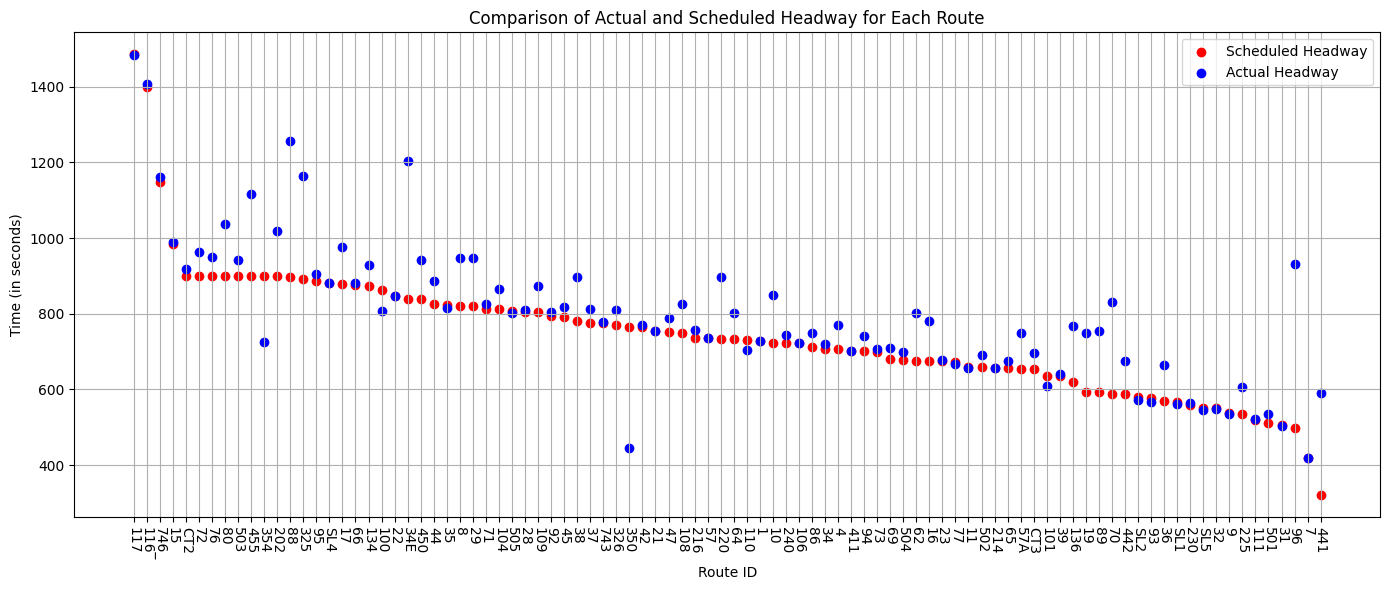

,headway,scheduled_headway,difference
route_id,,,
117,1484.452265,1485.686800,-1.234535
116,1406.329471,1399.465649,6.863822
746_,1160.808720,1148.045007,12.763713
15,989.232289,984.415452,4.816837
CT2,918.062914,900.000000,18.062914
...,...,...,...
501,534.247285,511.077694,23.169591
31,504.170023,504.890679,-0.720656
96,932.418605,498.837209,433.581395


In [5]:
wait_time("arrdep_18augsep_simplecleaned.csv")